In [93]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import qutip as qt

In [96]:
# default operators  (will probably be supplied by a static Hamiltonian class later)
Ix = qt.jmat(7/2, 'x')  # Spin-7/2 Ix operator
Iy = qt.jmat(7/2, 'y')  # Spin-7/
Iz = qt.jmat(7/2, 'z')  # Spin-7/2 Iz operator

# Drives are added to the PulseSequence class which can have a frequency and operator to create drive signals
class Drive:
    def __init__(self, name, operator, order=1, frequencies=[]):
        self.name = name
        self.frequencies = frequencies  # List of frequencies for the drive
        self.nr_channels = len(frequencies)  # Number of frequency channels
        self.order = order
        self.operator = operator  # operators for the drive 
        self.default_amp = 1.0  # Default amplitude for pulses
        self.default_pulse_shape = None  # Default pulse shape for pulses
        self.pi_times = np.ones(self.nr_channels).tolist()
        self.split_op_list = self.split_operator()  # List to hold split operators
        self.DriveSignal = None  # Placeholder for linked DriveSignal instance
        self.colormap = None  # color map for plotting

    
    def split_operator(self):
        '''Splits the operator into individual transition operators based on the order of the drive.'''
        op = self.operator.full()

        self.split_op_list = []
        for i in range(op.shape[0] - self.order):
            split_op = np.zeros((8, 8), dtype=np.complex128)
            split_op[i, i+self.order] = op[i, i+self.order]
            self.split_op_list.append(qt.Qobj(split_op))  # Append the operator to the list
        return self.split_op_list
    
    def Hdim(self):
        return (self.operator.full()).shape[0]
    def single_freq_drive(self, index, T, amp=None, pulse_shape=None, freq_mod=True):
        if amp is None:
            amp = self.default_amp
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        dt = self.DriveSignal.dt
        time_array = np.arange(0, T, dt)

        freq_mod_pulse = None # default no freq modulation otherwise will be overwritten
        if pulse_shape is None:
            # if no pulse shape provided we use a simple rectangular pulse
            pulse = amp * np.ones(len(time_array)) 
        else:
            # pulse shapes are taken from the pulse shape dict
            pulse = amp * pulse_shape.get_pulse(time_array, T)
            if freq_mod:
                freq_mod_pulse = pulse_shape.get_freq_modulation(time_array, T)
            
        self.DriveSignal.single_channel_update(self.name, index, pulse, freq_mod_pulse=freq_mod_pulse)

    def global_pulse(self, T, amp=None, pulse_shape=None, freq_mod_signal=None, square_freq_mod=False):
        '''Generates a global pulse for the specified drive.
        freq_mod_signal: optional frequency modulation with the amplitude of the pulse (needed for Ix^2 driving).
        Needs a list/array of scalars that will apply the frequency modulation at the different RF frequencies. 
        Example: Iz-like modulation [1]*7 and Iz^2 like modulation [-3, -2, -1, 0, 1, 2, 3]
        if set to None, no frequency modulation will be applied.
        '''
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        dt = self.DriveSignal.dt

        if freq_mod_signal is not None:
            self.align() # can only do self-consistent frequency modulation if all drives aligned


        if amp is None:
            amp = self.default_amp

        self.align()
        for i in range(self.nr_channels):
            self.single_freq_drive(i, T, amp, pulse_shape=pulse_shape)

    
    def align(self, index=None):
        """Aligns the drive signals by padding them to the same length."""
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        if index is None:
            self.DriveSignal.align(self.name)
        elif isinstance(index, list):
            drive_dict = {self.name: index}
            self.DriveSignal.align(drive_dict)
        else:
            drive_dict = {self.name: [index]}
            self.DriveSignal.align(drive_dict)

    def wait(self, T, index=None):
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        if index is None:
            self.global_pulse(T, amp=1e-34, pulse_shape=None)
        elif isinstance(index, list) or isinstance(index, np.ndarray):
            if isinstance(index, np.ndarray):
                index = index.tolist()
            self.align(index=index)
            for i in index:
                self.single_freq_drive(i, T, amp=1e-34, pulse_shape=None)
        elif isinstance(index, int) or isinstance(index, np.integer) or isinstance(index, np.int64):
            self.single_freq_drive(index, T, amp=1e-34, pulse_shape=None)
        else:   
            raise ValueError("Index must be None, a list, or a numpy array.")
        
    def frame_rotation(self, angles, index=None):
        """Rotates the phase of the drive signal by the specified angles.
        - If index is None, rotates all frequencies of the drive.
        - If index is specified, rotates only the specified frequency of the drive.
        """
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        self.DriveSignal.frame_rotation(self.name, angles, index)
    
    def set_detuning(self, detunings):
        """Sets the detuning for the specified drive. Can only be used for one drive at a time.
        - detunings can be a list of detuning values or a single detuning value.
        - If detunings is a list, it must match the number of frequencies in the drive.
        - If detunings is a single value, it applies to all frequencies of the drive.

        """
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        self.DriveSignal.set_detuning(self.name, detunings)

    def add_detuning(self, detunings):
        """Adds to the current detuning for the specified drive. Can only be used for one drive at a time.
        - detunings can be a list of detuning values or a single detuning value.
        - If detunings is a list, it must match the number of frequencies in the drive.
        - If detunings is a single value, it applies to all frequencies of the drive.

        """
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        self.DriveSignal.add_detuning(self.name, detunings)

    def calculate_default_pi_times(self):
        """Calculates the default pi times for each frequency channel based on the default amplitude."""

        if len(self.frequencies) != len(self.split_op_list):
            raise ValueError("Number of frequencies must match number of coupling elements of operator.")
        self.pi_times = []
        for i in range(len(self.frequencies)):
            T_pi = 1 / (2 * self.default_amp * np.abs(np.max(self.split_op_list[i].full())))  # Duration of a pi pulse based on the default amplitude
            self.pi_times.append(T_pi)
        return self.pi_times
    
    def rotation(self, angle, index, amp=None, pulse_shape=None):
        """Performs a rotation by the specified angle on the transition corresponding specified frequency index."""
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        
        if len(self.pi_times) < index + 1:
            raise ValueError("No pi time specified for the given index. Please add pi times or use calculate_default_pi_times() to get a default pi time for each transition.")
        
        if amp is None:
            amp = self.default_amp
        if pulse_shape is None:
            pulse_shape = self.default_pulse_shape

        if isinstance(index, list) or isinstance(index, np.ndarray):
            for i in index:
                T = angle / (2 * np.pi)* self.pi_times[i]/ amp # Duration of the pulse based on the angle and amplitude
                self.single_freq_drive(i, T, amp, pulse_shape=pulse_shape)
        else:
            T = angle / (2 * np.pi)* self.pi_times[index] / amp  # Duration of the pulse based on the angle and amplitude
            self.single_freq_drive(index, T, amp, pulse_shape=pulse_shape)

    def pi_pulse(self, index, amp=None, pulse_shape=None):
        """Performs a pi pulse on the transition corresponding to the specified frequency index."""
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        if amp is None:
            amp = self.default_amp  
        self.rotation(np.pi, index, amp, pulse_shape=pulse_shape)   

    def pi_half_pulse(self, index, amp=None, pulse_shape=None):
        """Performs a pi/2 pulse on the transition corresponding to the specified frequency index."""
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        if amp is None:
            amp = self.default_amp  
        self.rotation(np.pi/2, index, amp, pulse_shape=pulse_shape)   

    def ladder(self, start_idx, stop_idx, amp=None,  pulse_shape=None):
        """Performs a ladder operation from start_idx to stop_idx."""
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not linked to Drive.")
        if amp is None:
            amp = self.default_amp  
        used_idxs = np.arange(min(start_idx, stop_idx), max(start_idx, stop_idx)).tolist()
        self.align(index=used_idxs)
        if start_idx < stop_idx:
            for i in range(start_idx, stop_idx):
                self.pi_pulse(i, amp, pulse_shape=pulse_shape)
                self.align(index=used_idxs)
        else:
            for i in range(start_idx, stop_idx, -1):
                self.pi_pulse(i-1, amp, pulse_shape=pulse_shape)
                self.align(index=used_idxs)

# Default drives
NMR = Drive(name='NMR',
            frequencies=[],
            order=1,
            operator=-Iy)

NER1 = Drive(name='NER1',
            frequencies=[],
            order=1,
            operator=Iz*Ix+Ix*Iz)

NER2 = Drive(name='NER2',
            frequencies=[],
            order=2,
            operator=Ix**2-Iy**2)   

class PulseShape:
    def __init__(self, name, function, args={}, normalize_total_amp=False):
        self.name = name
        self.function = function  # Function that defines the pulse shape
        self.freq_modulation_function = None # Amplitude has to be given wrt the actual function, which should have max(abs(function))=1, so if the freq mod fun has a max of 0.5 it will be half as strong as the normal function
        self.detuning = None  # Detuning is intepreted as dc frequency modulation and will overwrite any freq modulation function
        self.args = args  # Additional arguments for the pulse shape function
        self.check_function()
        self.amp_rescaling = 1.0

        self.normalize_total_amp = normalize_total_amp
        if self.normalize_total_amp:
            self.amp_rescaling = self.normalize_the_total_amp_area()

    def check_function(self, function=None):
        """Checks if the pulse shape function works correctly."""
        t = np.linspace(0, 1, 100)
        T = 1
        if function is None:
            function = self.function
        try:
            pulse = function(t, T, **self.args)
        except Exception as e:
            raise ValueError(f"Pulse shape function raised an error: {e} \n \
                             Please ensure the function has the signature function(t, T, **kwargs).")
        if len(pulse) != len(t):
            raise ValueError("Pulse shape function must return an array of the same length as the time array.")
        if np.max(np.abs(pulse)) > 1.01 or np.max(np.abs(pulse)) < 0.99:
            raise ValueError("Pulse shape should be normalized to a maximum amplitude of 1.")
        return True
    
    def normalize_the_total_amp_area(self):
        ''' rescales amp such that pi-time is the same as for square pulse of same total T'''
    
        dt = 1e-6 # since T=1 s dt will be a bit higher than usual 
        T = 1
        t = np.arange(0, T, dt)
        pulse = self.function(t, T, **self.args)
        # if np.max(np.abs(pulse)) > 1.01 or np.max(np.abs(pulse)) < 0.99:
        #     raise ValueError("Pulse shape should be normalized to a maximum amplitude of 1 before normalizing total area.")
        
        total_area = np.sum(pulse) * dt
        self.amp_rescaling = 1 / total_area # area of square pulse with amp 1 is T=1 is 1
        
        return self.amp_rescaling
    def get_pulse(self, t, T):
        ''' returns the pulse shape at time t for total duration T, rescaled by amp_rescaling'''
        if self.normalize_total_amp:
            self.amp_rescaling = self.normalize_the_total_amp_area()
        else:
            self.amp_rescaling = 1.0
        return self.amp_rescaling * self.function(t, T, **self.args)
    
    def get_freq_modulation(self, t, T):
        ''' returns the frequency modulation at time t for total duration T'''
        if self.detuning is not None:
            return np.ones(len(t)) * self.detuning
        
        if self.freq_modulation_function is None:
            return np.zeros(len(t))
        else:
            return self.amp_rescaling * self.freq_modulation_function(t, T, **self.args)

    def example_function(self, t, T, **kwargs):
        """Example pulse shape function: Gaussian pulse."""
        sigma = kwargs.get('sigma', T / 6)
        return np.exp(-0.5 * ((t - T / 2) / sigma) ** 2)
    
    def plot(self):
        if self.normalize_total_amp:
            self.amp_rescaling = self.normalize_the_total_amp_area()
        else:
            self.amp_rescaling = 1.0
        plt.figure(figsize=(8, 3))
        plt.plot(np.linspace(0, 1, 100), self.get_pulse(np.linspace(0, 1, 100), 1))

    ### Needs freq modualtion capability ###

# Default pulse shapes

def Hann_function(t, T):
    Hf = np.zeros(len(t), dtype=np.complex128)
    Hf = np.sin(np.pi * t / T) **2
    return Hf

Hann = PulseShape(name='Hann', function=Hann_function, normalize_total_amp=True)

def sin_sq_env(t, T, Trise):
    return ((np.heaviside(t, 1) - np.heaviside(t - Trise*T, 1)) * np.sin(np.pi/2*t/(Trise*T))**2 + \
        (np.heaviside(t - Trise*T, 1) - np.heaviside(t - (1-Trise)*T, 1)) + \
        (np.heaviside(t - (1-Trise)*T, 1) - np.heaviside(t - T, 1)) * np.sin(np.pi/2*(t-(T-Trise*T))/(Trise*T) + np.pi/2)**2)

sin_rise_fall = PulseShape(name='sin_rise_fall', function=sin_sq_env, args={'Trise': 0.1}, normalize_total_amp=True)

def sin_sq_rise(t, T):
    return   np.sin(np.pi/2*t/(T))**2 
sin_rise = PulseShape(name='sin_rise', function=sin_sq_rise, normalize_total_amp=False)

def sin_sq_fall(t, T):
    return   np.sin(np.pi/2*t/(T)+np.pi/2)**2 
sin_fall = PulseShape(name='sin_fall', function=sin_sq_fall, normalize_total_amp=False)

# the DriveSignal stores all drive signals given by different drives that are added to the PulseSequence
class DriveSignal:
    def __init__(self, dt=1e-6, drive_list=[]):
        self.dt = dt  # Time step for the simulation
        self.drive_signals = {} # will hold all signals
        self.clocks = {}
        self.detunings = {}
        self.Hdim = 8
        self.rotating_frame_detuning = np.zeros(self.Hdim) # eight is default but can be overwritten later
        self.freq_mod_signals = {}
        self.plot_freq_mod = False # will only plot if relevant
        self.drive_names = []
        self.active_drives = [] 
        self.time_array = np.array([0])  # Time array for the simulation
        self.init_drive_signal_dict(drive_list=drive_list)

    def init_drive_signal_dict(self, drive_list=[]):
        self.drive_signals = {} # will hold all singals     
        # Initialize colormaps for each drive for plotting   
        default_cmaps = ['Reds', 'Blues', 'Greens', 'Purples', 'Oranges', 'Greys', 'YlGnBu', 'PuRd']
        self.colormaps = {}
        self.active_drives = []

        for d, drive in enumerate(drive_list):
            if d == 0:
                self.Hdim = drive.operator.full().shape[0]  # Set Hdim based on the first drive's operator
                self.rotating_frame_detuning = np.zeros(self.Hdim) # initialize rotating frame detuning
                self.rotating_frame_detuning_signal = []
                for i in range(self.Hdim):
                    self.rotating_frame_detuning_signal.append([]) # will hold the detuning arrays for each level
            if drive.colormap is None:
                self.colormaps[drive.name] = default_cmaps.pop(0)
            else:
                self.colormaps[drive.name] = drive.colormap
            drive.nr_channels = len(drive.frequencies) # makes sure this is updated
            self.clocks[drive.name] = np.zeros(drive.nr_channels)  # Initialize clocks for each drive
            self.drive_signals[drive.name] = [] # A drive will have a list of arrays, one for each frequency
            self.freq_mod_signals[drive.name] = [] # will hold the detuning arrays for each drive
            for j in range(drive.nr_channels):
                self.drive_signals[drive.name].append([]) # this array will hold the signal for the given freqs
                self.freq_mod_signals[drive.name].append([]) # will hold the detuning arrays for each drive
            self.detunings[drive.name] = np.zeros(drive.nr_channels) # will hold the current detuning values for each drive
            
            if drive.nr_channels > 0:
                self.active_drives.append(drive.name) # only count drive with frequencies as active

    def single_channel_update(self, drive_name, index, pulse, freq_mod_pulse=None):
        """Appends the given pulse to the specified drive and index.
        """
        if isinstance(pulse, list):
            pulse = np.array(pulse)
        else:
            if not isinstance(pulse, np.ndarray):
                raise ValueError("Pulse must be a list or numpy array.")
        
        pulse = pulse * np.exp(1j * self.clocks[drive_name][index])  # Apply the current phase from the clock
        self.drive_signals[drive_name][index].extend(pulse.tolist())

        # frequency modulation
        if freq_mod_pulse is None:
            freq_mod_pulse = np.zeros(len(pulse))
        else:
            if len(freq_mod_pulse) != len(pulse):
                raise ValueError("Frequency modulation pulse must be the same length as the drive pulse.")
        freq_mod_pulse += self.detunings[drive_name][index]  # Apply the current detuning
        self.freq_mod_signals[drive_name][index].extend(freq_mod_pulse.tolist())
    

    def frame_rotation(self, drive_name, angles, index=None):
        """Rotates the phase of the drive signal by the specified angles.
        - If index is None, rotates all frequencies of the drive.
        - If index is specified, rotates only the specified frequency of the drive.
        """
        if index is None:
            for i in range(len(self.drive_signals[drive_name])):
                self.clocks[drive_name][i] += angles[i] if isinstance(angles, list) else angles  # Rotate all frequencies by the specified angle
        else:
            if isinstance(angles, list) or isinstance(angles, np.ndarray):
                if len(angles) != len(self.drive_signals[drive_name]):
                    raise ValueError("Length of angles list must match the number of frequencies in the drive.")
            if index >= len(self.drive_signals[drive_name]):
                raise IndexError(f"Index {index} out of range for drive {drive_name}.")
            
            if isinstance(angles, list) or isinstance(angles, np.ndarray):
                for i in index:
                    self.clocks[drive_name][i] += angles[i]  # Rotate the specified frequency by the specified angle
            else:
                self.clocks[drive_name][index] += angles   

    def set_detuning(self, drive_name, detunings):
        """Sets the detuning for the specified drive. Can only be used for one drive at a time.
        - detunings can be a list of detuning values or a single detuning value.
        - If detunings is a list, it must match the number of frequencies in the drive.
        - If detunings is a single value, it applies to all frequencies of the drive.

        """
        if drive_name not in self.drive_signals:
            raise ValueError(f"Drive '{drive_name}' not found in drive signals.")
        if isinstance(detunings, list) or isinstance(detunings, np.ndarray):
            if len(detunings) != len(self.drive_signals[drive_name]):
                raise ValueError("Length of detunings list must match the number of frequencies in the drive.")
        else:
            detunings = [detunings] * len(self.drive_signals[drive_name])  # If a single detuning is provided, apply it to all frequencies

        for i in range(len(self.drive_signals[drive_name])):
            self.detunings[drive_name][i] = detunings[i]

    def add_detuning(self, drive_name, detunings):
        """Adds to the current detuning for the specified drive. Can only be used for one drive at a time.
        - detunings can be a list of detuning values or a single detuning value.
        - If detunings is a list, it must match the number of frequencies in the drive.
        - If detunings is a single value, it applies to all frequencies of the drive.

        """
        if drive_name not in self.drive_signals:
            raise ValueError(f"Drive '{drive_name}' not found in drive signals.")
        if isinstance(detunings, list) or isinstance(detunings, np.ndarray):
            if len(detunings) != len(self.drive_signals[drive_name]):
                raise ValueError("Length of detunings list must match the number of frequencies in the drive.")
        else:
            detunings = [detunings] * len(self.drive_signals[drive_name])  # If a single detuning is provided, apply it to all frequencies

        for i in range(len(self.drive_signals[drive_name])):
            self.detunings[drive_name][i] += detunings[i]
    
    def set_RF_detuning(self, detunings):
        """Sets the rotating frame detuning for the system.
            HAS IMPLICIT ALING
        - detunings can be a list of detuning values or a single detuning value.
        - If detunings is a list, it must match the Hdim of the system.
        - If detunings is a single value, it applies to all levels of the system.

        """
        self.align() # since the rotating rame is shared between all channels we align first

        # update the rotating frame detuning signal up to the current time
        current_detuning_signal_length = len(self.rotating_frame_detuning_signal[0]) # check how long the detuning signal is so far
        current_pulse_length = len(self.drive_signals[self.active_drives[0]][0])  # assuming all drives are aligned
        if current_detuning_signal_length < current_pulse_length:
            for i in range(self.Hdim): # extend the detuning signal to the current pulse length
                self.rotating_frame_detuning_signal[i].extend([self.rotating_frame_detuning[i]] * (current_pulse_length - current_detuning_signal_length))
        # after updating the detuning signal to current point we update the detunings for the future
        if isinstance(detunings, list) or isinstance(detunings, np.ndarray):
            if len(detunings) != self.Hdim - 1:
                raise ValueError("Length of detunings list must match the Hdim of the system.")
            self.rotating_frame_detuning = np.array(detunings)
        else:
            self.rotating_frame_detuning = np.ones(self.Hdim) * detunings  # If a single detuning is provided, apply it to all levels

    def align(self, drives='all'):
        """Aligns the drive signals for the specified drives by padding them to the same length.
        - If 'all' is specified, aligns all drive signals.
        - if drives is a drive name or list of drive names it aligns all frequencies of the specified drives.
        - if drives is a dictionary, it aligns the specified frequencies of the drives. As
            drives = {
                'drive1': [freq_index1, freq_index2, ...],
                ...
            }
        """
        if isinstance(drives, dict):
            to_align = drives  # Use the provided dictionary to align specific frequencies
        elif isinstance(drives, list):

            # add all frequencies of all drives to the list to align
            to_align = {}
            for drive_name in drives:
                to_align[drive_name] = list(range(len(self.drive_signals[drive_name])))  # Align all frequencies of the driv

        elif isinstance(drives, str):
            if drives == 'all':
                all_drives = self.drive_signals.keys()
                # add all frequencies of all drives to the list to align
                to_align = {}
                for drive in all_drives:
                    to_align[drive] = list(range(len(self.drive_signals[drive])))  # Align all frequencies of the drive
            else:
                to_align = {}
                to_align[drives] = list(range(len(self.drive_signals[drives])))  # Align all frequencies of the driv

        # Find the longest channel among the drives to align
        longest_channel = 0
        for drive_name in to_align.keys():
            for i in to_align[drive_name]: 
                if len(self.drive_signals[drive_name][i]) > longest_channel:
                    longest_channel = len(self.drive_signals[drive_name][i])
        # add padding to all channels to make them the same length
        for drive_name in to_align.keys():
            for i in to_align[drive_name]: 
                if len(self.drive_signals[drive_name][i]) < longest_channel:
                    padding = longest_channel - len(self.drive_signals[drive_name][i])
                    self.drive_signals[drive_name][i].extend([1e-34*np.exp(1j*self.clocks[drive_name][i])] * padding)
                    self.freq_mod_signals[drive_name][i].extend([self.detunings[drive_name][i]] * padding)

    def check_active_drives(self):
        self.active_drive_dict = {}
        for drive_name in self.active_drives:
            self.active_drive_dict[drive_name] = []
            active = False
            for idx in range(len(self.drive_signals[drive_name])):
                if np.max(np.abs(np.array(self.drive_signals[drive_name][idx]))) > 1e-10:
                    active = True
                    self.active_drive_dict[drive_name].append(idx)
            if not active:
                self.active_drives.remove(drive_name)    
        return self.active_drive_dict

    def plot_signal(self, drives='all', freq_index=None, ax=None):
        """Plots the drive signals for the specified drives and frequency index."""
        # if not self.finish_pulse_sequence:
        #     self.finish_pulse_sequence()  # Ensure the pulse sequence is finished before plotting

        if drives == 'all':
            to_plot = self.drive_signals.keys()
        else:
            to_plot = drives if isinstance(drives, list) else [drives]
        nrows = 2
        for drive in to_plot:
            for idx in range(len(self.freq_mod_signals[drive])):
                if np.max(np.abs(np.array(self.freq_mod_signals[drive][idx]))) > 1e-10:
                    self.plot_freq_mod = True
                    nrows = 3
        if ax is None:
            figsize = (10, 3*nrows)
            fig, ax = plt.subplots(nrows, 1, figsize=figsize, sharex=True)  # Create a figure with two subplots if no axes are provided

        for drive in to_plot: 
            if drive in self.active_drives:
                colors = mpl.cm.get_cmap(self.colormaps[drive])(np.linspace(0.4, 1, len(self.drive_signals[drive])))
                if freq_index is None:
                    for i in range(len(self.drive_signals[drive])):
                        time_array = 1e6 * np.linspace(0, len(self.drive_signals[drive][i]) * self.dt, len(self.drive_signals[drive][i]))
                        ax[0].plot(time_array, np.abs(self.drive_signals[drive][i]), label=f'{drive} freq {i}', color=colors[i], alpha=0.5)
                        ax[1].plot(time_array, np.angle(self.drive_signals[drive][i]), label=f'{drive} freq {i}', color=colors[i], alpha=0.5)
                        # if not self.selfconsistent_FM:
                        if self.plot_freq_mod:
                            ax[2].plot(time_array, self.freq_mod_signals[drive][i], label=f'{drive} freq {i}', color=colors[i], alpha=0.5)
                else:
                    time_array = 1e6 * np.linspace(0, len(self.drive_signals[drive][freq_index]) * self.dt, len(self.drive_signals[drive][freq_index]))
                    ax[0].plot(time_array, np.abs(self.drive_signals[drive][freq_index]), label=f'{drive} freq {freq_index}', color=colors[freq_index])
                    ax[1].plot(time_array, np.angle(self.drive_signals[drive][freq_index]), label=f'{drive} freq {freq_index}', color=colors[freq_index])
                    if self.plot_freq_mod:
                            ax[2].plot(time_array, self.freq_mod_signals[drive][freq_index], label=f'{drive} freq {freq_index}', color=colors[freq_index], alpha=0.5)

        ax[0].set_xlabel('Time ($\mu$ s)')
        ax[0].set_ylabel('Amplitude (Hz)')
        ax[1].set_ylabel('Phase (rad)')
        ax[0].legend(ncols = len(self.active_drives))
        ax[0].set_title('Drive Signals')
        if self.plot_freq_mod:
            ax[2].set_xlabel('Time ($\mu$ s)')
            ax[2].set_ylabel('Frequency Detuning (Hz)')
            # ax[2].set_title('Frequency Modulation Signals')
        plt.show()

# Pulse sequence class collects drives, pulse shapes and other commands / parameters. It initialized the DriveSignal and handels the pulse sequence creation.
class PulseSequence:
    def __init__(self, pulse_shapes=[], dt=1e-6):
        self.dt = dt  # Time step for the simulation
        self.finished_pulse_sequence = False  # Flag to indicate if the pulse sequence is finished
        self.time_array = np.array([0])  # Time array for the simulation
        self.pulse_shapes = pulse_shapes
        self.DriveSignal = None
        # deflault drives:
        self.NMR = NMR 
        self.NER1 = NER1
        self.NER2 = NER2
        self.start_pulse_sequence()
        

    def make_drive_dict(self):
        self.drive_dict = {name: value for name, value in vars(self).items() if isinstance(value, Drive)}
        self.drive_list = list(self.drive_dict.values())
        self.drive_names = list(self.drive_dict.keys())

    def init_drive_signal(self):
        self.make_drive_dict()
        self.DriveSignal = DriveSignal(dt=self.dt, drive_list=self.drive_list)
        for drive in self.drive_list:
            drive.DriveSignal = self.DriveSignal  # Link the DriveSignal instance to each Drive
            
    def start_pulse_sequence(self):
        self.finished_pulse_sequence = False
        self.init_drive_signal()
        
    def align(self):
        """Align all channels of all drives.
        """
        self.DriveSignal.align()
        
    def wait(self, T):
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not initialized. Call init_drive_signal() first.")
        
        self.DriveSignal.align()
        for drive in self.drive_list:
            drive.wait(T)

    def oscillator_FM(self, time_array, base_freq, FM_signal):
        """Generate a frequency-modulated signal.

            Parameters:
            base_freq : float
                Base frequency in Hz.
            mod_signal : array_like
                Time-dependent modulation signal in Hz, same length as t.
            t : array_like
                Time array in seconds.

            Returns:
            signal : ndarray
                Output FM signal with amplitude 1."""
            # Ensure arrays
        assert len(time_array) == len(FM_signal), "Time array and modulation signal must have the same length."

        # Instantaneous frequency
        inst_freq = base_freq + FM_signal
        # Integrate to get phase
        phase = 2 * np.pi * np.cumsum(inst_freq) * (time_array[1] - time_array[0])
        # Output sine wave
        return np.exp(1j * phase)

    def set_selfconsistent_detuning(self, detunings):
        """Sets the detuning for all drives in a self-consistent manner.
        - detunings must be a list of length equal to number of 1st order drives.
        - the detuning on second order drives is calculated in a self-consistent manner.
        - if selfconsistent_FM is True an align will be applied
        """
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not initialized. Call init_drive_signal() first.")
        
        self.align()
        for drive in self.drive_list:
            if len(drive.frequencies) != (drive.operator.full()).shape[0] - drive.order:
                print("For drive ", drive.name, " the number of frequencies does not match the number of coupling elements of the operator. Cannot set self-consistent detuning.")
            else:
                det_freqs = np.zeros(len(drive.frequencies))
                for i in range(len(drive.frequencies)):
                    det_freqs[i] = np.sum(detunings[i:i+drive.order])  # For higher order drives, sum the frequencies

                drive.set_detuning(det_freqs)  # Set the detuning for the drive

    def add_selfconsistent_detuning(self, detunings):
        """Adds the detuning for all drives in a self-consistent manner.
        - detunings must be a list of length equal to number of 1st order drives.
        - the detuning on second order drives is calculated in a self-consistent manner.
        - if selfconsistent_FM is True an align will be applied
        """
        if self.DriveSignal is None:
            raise ValueError("DriveSignal instance not initialized. Call init_drive_signal() first.")
        
        self.align()
        for drive in self.drive_list:
            if len(drive.frequencies) != (drive.operator.full()).shape[0] - drive.order:
                print("For drive ", drive.name, " the number of frequencies does not match the number of coupling elements of the operator. Cannot set self-consistent detuning.")
            else:
                det_freqs = np.zeros(len(drive.frequencies))
                for i in range(len(drive.frequencies)):
                    det_freqs[i] = np.sum(detunings[i:i+drive.order])  # For higher order drives, sum the frequencies

                drive.add_detuning(det_freqs)  # Set the detuning for the drive

    def finish_pulse_sequence(self):
        """Aligns all drive signals and pads them to the same length."""
        self.align()  # Aligns all drive signals
        self.time_array = np.linspace(0, len(list(self.DriveSignal.drive_signals.values())[0][0]) * self.dt, len(list(self.DriveSignal.drive_signals.values())[0][0]), endpoint=False)  # Creates a time array based on the length of the first drive signal
        self.finished_pulse_sequence = True  # Set the flag to indicate that the pulse sequence is finished
        self.active_drive_dict = self.DriveSignal.check_active_drives()

    def plot_signal(self, drives='all', freq_index=None, ax=None):
        """Plots the drive signals for the specified drives and frequency index."""
        self.DriveSignal.plot_signal(drives, freq_index, ax)

    def get_drive_hamiltonian(self, rotating_frame_frequencies, cross_coupling_cutoff_frequency=None, add_cross_coupling=True, detune_through_operator=True):
        """Generates the Hamiltonian for the drive signals."""
        if not self.finished_pulse_sequence:
            self.finish_pulse_sequence()
        if cross_coupling_cutoff_frequency is None:
            cross_coupling_cutoff_frequency = 1e34  # bigger than anything
        if add_cross_coupling is False:
            cross_coupling_cutoff_frequency = 1e-3  # smaller than anything other than on resonance (doesn't take into acount detunings)

        self.GRF = True # generalized rotating frame 
        if len(rotating_frame_frequencies) == 1:
            self.GRF = False # zeeman rotating frame

        DriveHam = [] # drive hamiltonian in QuTiP list format

        # doing detuning through digaonal operator rather than changing the frequencies
        Vdetuning_ops = []
        d =8
        for i in range(d-1):
            op = np.diag([1]*(i+1) + [-1]*(d-(i+1)))/2
            Vdetuning_ops.append(qt.Qobj(op))
        detune_ops_added = False
        
        for drive in self.drive_list:
            if self.GRF: # in GRF we need to treat every transition seperately
                d = drive.Hdim()
                RF_freqs = np.zeros(d - drive.order) # effective rotating frame frequencies
                for i in range(len(RF_freqs)):
                    RF_freqs[i] = np.sum(rotating_frame_frequencies[i:i+drive.order])  # For higher order drives, sum the frequencies
                    
                for op_index, op in enumerate(drive.split_op_list): # all different transitions of the operator we drive
                    signal = np.zeros(len(self.time_array), dtype=np.complex128)  # Initialize the signal for the drive

                    for freq_index, freq in enumerate(drive.frequencies): # loop over the drive frequencies
                        if np.abs(RF_freqs[op_index] - freq) <= np.ceil(cross_coupling_cutoff_frequency): # we can exclude high_frequency cross-coupling
                            amps = np.array(self.DriveSignal.drive_signals[drive.name][freq_index])
                            f = (freq - RF_freqs[op_index]) # frequency in the gen rotating frame
                           
                            if not detune_through_operator:
                                freq_mod_signal = self.DriveSignal.freq_mod_signals[drive.name][freq_index]
                                signal += amps * 2* np.pi * self.oscillator_FM(self.time_array, f, freq_mod_signal) #np.exp(1j * 2 * np.pi * f * self.time_array)
                            else:
                                signal += amps * 2* np.pi * np.exp(1j * 2 * np.pi * f * self.time_array)
                                # add detuning through diagonal operator
                                
                                detune_signal = np.array(self.DriveSignal.freq_mod_signals[drive.name][freq_index])
                                if np.max(np.abs(detune_signal)) > 1e-10:
                                    DriveHam.append([Vdetuning_ops[op_index], detune_signal])

                    if len(signal) != len(self.time_array):
                        raise ValueError(f"Signal length for {drive.name} frequency {freq_index} does not match time array length.")
                    
                    if np.max(np.abs(signal)) > 1e-10:  # Only add non-zero signals
                        DriveHam.append([op, signal])
                        DriveHam.append([op.dag(), np.conj(signal)])
                        
            else: # zeeman rotating frame
                pass

        return DriveHam, self.time_array  # Returns the Hamiltonian and the time array for the drive signals
    


# test zone

In [97]:
# setting some drive parameters
nmr_f = np.linspace(7.6e6, 7.72e6, 7)
ner_f = nmr_f[1:] + nmr_f[:-1]


NMR.frequencies = nmr_f
NER2.frequencies = ner_f
NMR.default_amp = 100
NER2.default_amp = 50
nmr_pi_times = NMR.calculate_default_pi_times()

In [64]:
Hann_freq_mod = PulseShape(name='Hann', function=Hann_function, normalize_total_amp=True)
Hann_freq_mod.freq_modulation_function = Hann_function


For drive  NER1  the number of frequencies does not match the number of coupling elements of the operator. Cannot set self-consistent detuning.


C:\Users\z5459883\AppData\Local\Temp\ipykernel_52468\3181704566.py:540: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = mpl.cm.get_cmap(self.colormaps[drive])(np.linspace(0.4, 1, len(self.drive_signals[drive])))


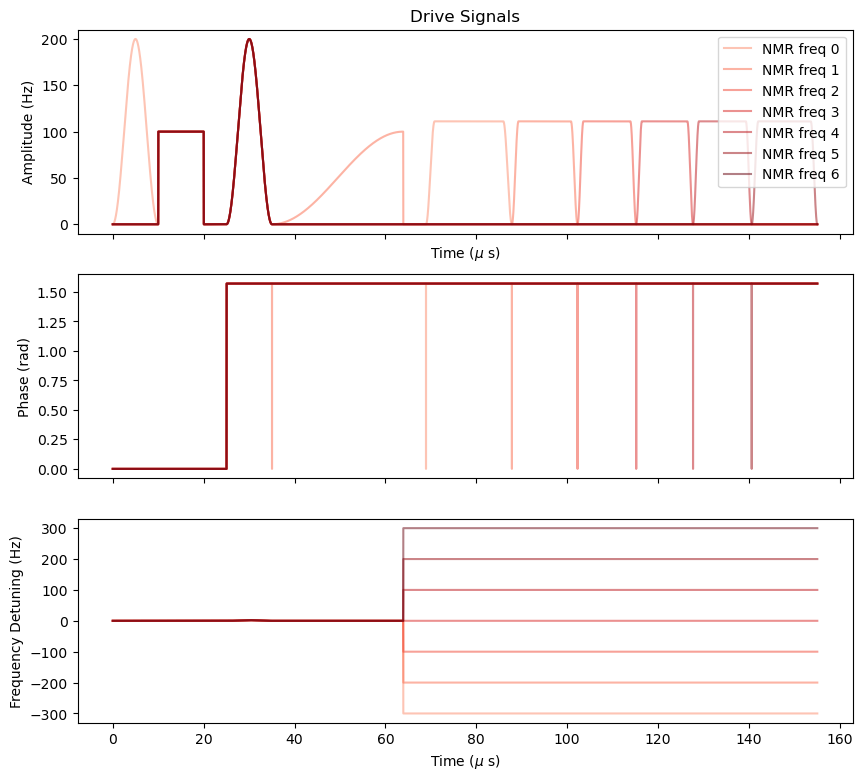

In [5]:
ps = PulseSequence(dt=1e-8)
ps.NMR.single_freq_drive(0, T=10e-6, pulse_shape=Hann)
ps.NMR.align()
ps.NMR.global_pulse(T=10e-6)
ps.align()  # Aligns all drive signals
ps.wait(T=5e-6)
ps.NMR.frame_rotation(np.pi/2)
ps.NMR.global_pulse(T=10e-6, pulse_shape=Hann_freq_mod)
ps.align()
ps.NMR.rotation(np.pi*2, index=1, pulse_shape=sin_rise)
ps.set_selfconsistent_detuning(np.arange(-3, 4)*1e2)  # set detunings for 1st order drives, 2nd order drives will be set self-consistently
# ps.NER2.global_pulse(T=10e-6)
ps.NMR.wait(T=5e-6)
ps.NMR.ladder(0, 6, pulse_shape=sin_rise_fall)

ps.finish_pulse_sequence()  
ps.plot_signal()

In [6]:
H, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=nmr_f, cross_coupling_cutoff_frequency=None)

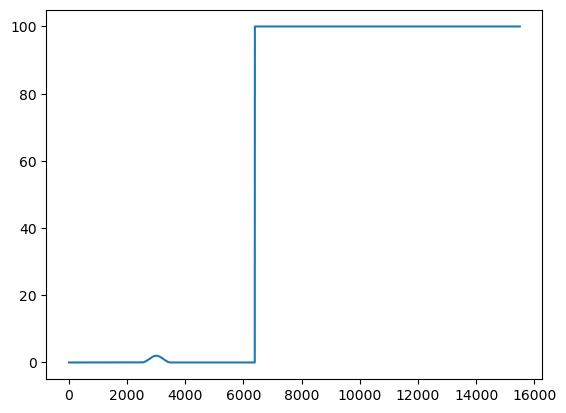

In [7]:
plt.plot(np.real(H[4][1]))

# Static Hamiltonian

In [8]:
class Spin:
    def __init__(self, spin_nr, NMR_frequencies=None):
        self.spin = spin_nr  # Spin value for the qudit
        self.spin_nr = spin_nr
        self.d = int(2 * spin_nr + 1)  # Dimension of the Hilbert space for the qudit

        self.Ix = qt.jmat(self.spin, 'x')
        self.Iy = qt.jmat(self.spin, 'y')
        self.Iz = qt.jmat(self.spin, 'z')
        self.Ix2 = qt.jmat(self.spin, 'x')**2
        self.Iy2 = qt.jmat(self.spin, 'y')**2
        self.Iz2 = qt.jmat(self.spin, 'z')**2
        self.parity_op =  qt.Qobj(np.eye(self.d) * np.array([1, -1] * (self.d//2)))

        self.Hstatic = 0*qt.identity(self.d)  # Initialize the Hamiltonian state to zero
        self.NMR_frequencies = np.zeros(self.d - 1) if NMR_frequencies is None else NMR_frequencies
        self.state_labels = [f'|{m}>' for m in range(int(-self.spin), int(self.spin)+1)]
        self.state = qt.basis(self.d, 0)  # Initialize the qudit in the lowest energy state

    def set_static_hamiltonian(self, fzeeman, fq, fq2=0):
        """Sets the static Hamiltonian for the qudit based on the given parameters."""
        self.Hstatic = fzeeman * self.Iz + fq * self.Iz**2 + fq2 * self.Iz**3 

    def calculate_NMR_frequencies(self):
        """Calculates the NMR frequencies for the qudit based on the static Hamiltonian."""
        energies = self.Hstatic.eigenenergies()
        self.NMR_frequencies = np.diff(energies)  # Calculate the transition frequencies
        return self.NMR_frequencies
        

def simulate(self, init_state, pulse_sequence, RF_frequencies=None):
    """Simulates the given pulse sequence on the qudit."""
    if not pulse_sequence.finished_pulse_sequence:
        pulse_sequence.finish_pulse_sequence()  # Ensure the pulse sequence is finished

    self.H_drive, self.time_array = pulse_sequence.get_drive_hamiltonian(rotating_frame_frequencies=self.NMR_frequencies)

    # Total Hamiltonian including static and drive terms
    H_total = [self.Hstatic, *self.H_drive]  # Static Hamiltonian term

    # Time evolution
    result = qt.mesolve(H_total, self.state, self.time_array, [], [])
    self.state = result.states[-1]  # Update the state to the final state after the pulse sequence
    return self.state

                         


In [9]:
fzeeman = 1
fq = 0.01
fq2 = 0
H = fzeeman * Iz + fq * Iz**2 + fq2 * Iz**3
H

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 3.6225  0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      2.5625  0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      1.5225  0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.5025  0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.     -0.4975  0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.     -1.4775  0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.     -2.4375  0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.     -3.3775]]

In [10]:
aGR = 1/6e-3
Tenc = 0.25/aGR

In [11]:
np.diff(nmr_f)

array([20000., 20000., 20000., 20000., 20000., 20000.])

For drive  NER1  the number of frequencies does not match the number of coupling elements of the operator. Cannot set self-consistent detuning.


C:\Users\z5459883\AppData\Local\Temp\ipykernel_52468\3181704566.py:540: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = mpl.cm.get_cmap(self.colormaps[drive])(np.linspace(0.4, 1, len(self.drive_signals[drive])))


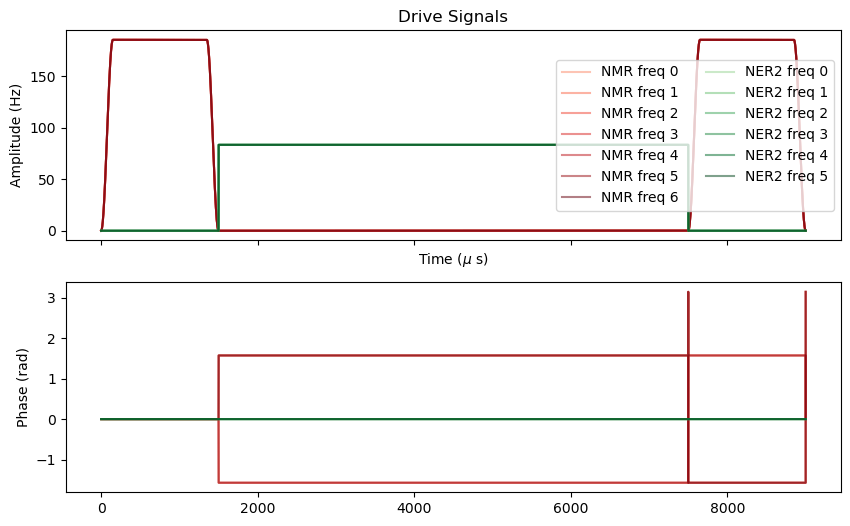

In [12]:
resonance_frequencies  = nmr_f
Hstatic = 0 * Iz + 0.01 * Iz**2
init_state = qt.basis(8, 7)

ps = PulseSequence(dt=1e-7)
ps.NMR.global_pulse(T=Tenc, amp=aGR, pulse_shape=sin_rise_fall)
ps.NMR.frame_rotation([np.pi/2, -np.pi/2, np.pi/2, -np.pi/2, np.pi/2, -np.pi/2, np.pi/2])
ps.align()
# ps.set_selfconsistent_detuning(np.arange(-3, 4) * aGR)  
ps.DriveSignal.set_RF_detuning(np.arange(-3, 4) * aGR)
ps.NER2.global_pulse(T=Tenc*4, amp=aGR/2, pulse_shape=None)
ps.align()
ps.set_selfconsistent_detuning(np.zeros(7))  
ps.NMR.global_pulse(T=Tenc, amp=-aGR, pulse_shape=sin_rise_fall)
ps.finish_pulse_sequence()
ps.plot_signal()

In [13]:
ps.DriveSignal.rotating_frame_detuning

array([-500.        , -333.33333333, -166.66666667,    0.        ,
        166.66666667,  333.33333333,  500.        ])

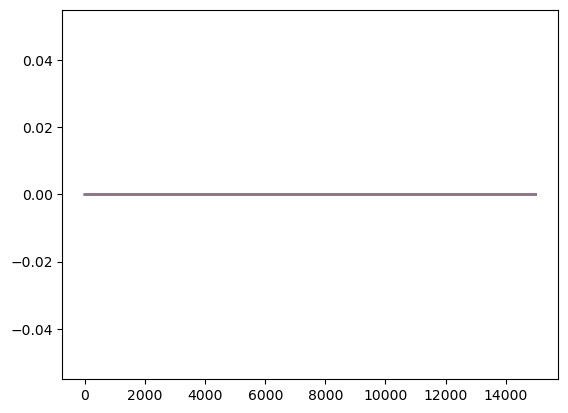

In [14]:
plt.plot(np.array(ps.DriveSignal.rotating_frame_detuning_signal).T)

In [15]:
fock_dms = []
for i in range(8):
    fock_dms.append(qt.basis(8, i) * qt.basis(8, i).dag())

[Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [1.]],
 Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[-3.10076106e-111+8.33749666e-127j]
  [-4.61743587e-096-2.67510074e-090j]
  [-1.56151734e-079-3.13760830e-067j]
  [ 1.84915772e-046-3.19951290e-056j]
  [ 1.87810444e-027-7.89731240e-036j]
  [ 1.71001850e-017-7.94824046e-025j]
  [ 1.58700726e-009-1.07037706e-016j]
  [ 1.00000000e+000-1.22500000e-008j]],
 Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[-7.82220660e-111+2.10327788e-126j]
  [-1.16482814e-095-6.74840475e-090j]
  [-3.93919783e-079-7.91516014e-067j]
  [ 4.66482049e-046-8.07132521e-056j]
  [ 4.73784360e-027-1.99223378e-035j]
  [ 4.31381771e-017-2.00508126e-024j]
  [ 3.99310627e-009-2.69977438e-016j]
  [ 1.00000000e+000-2.45000000e-008j]],
 Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qo

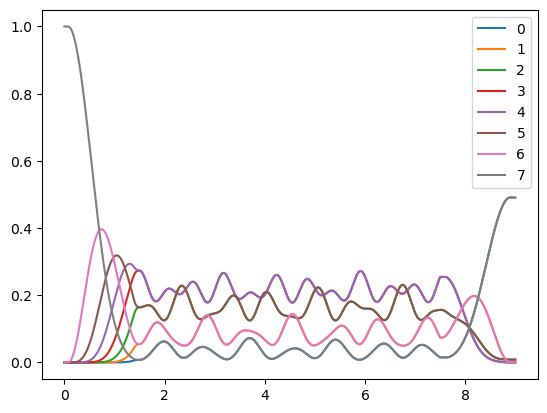

In [17]:
for i, exp in enumerate(sim_result.expect):
    plt.plot(time_array*1e3, np.real(exp), label=f'{i}')

plt.legend()

# Rabi's

In [38]:
transition_dict = [r'$|-7/2\rangle \leftrightarrow |-5/2\rangle$', r'$|-5/2\rangle \leftrightarrow |-3/2\rangle$', r'$|-3/2\rangle \leftrightarrow |-1/2\rangle$', r'$|-1/2\rangle \leftrightarrow |1/2\rangle$', r'$|1/2\rangle \leftrightarrow |3/2\rangle$', r'$|3/2\rangle \leftrightarrow |5/2\rangle$', r'$|5/2\rangle \leftrightarrow |7/2\rangle$']

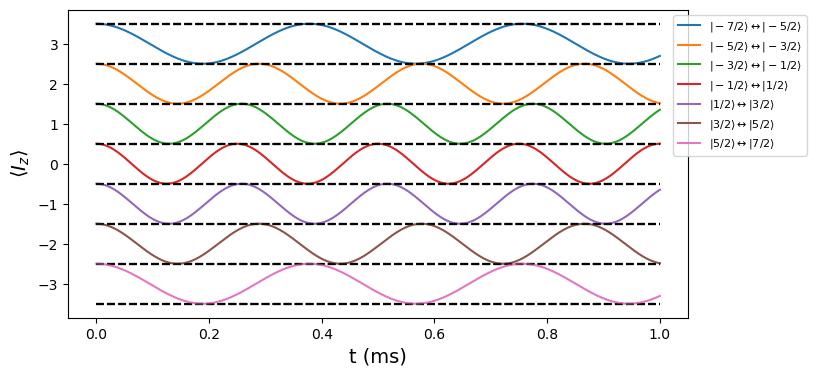

In [55]:
init_states = [0, 1, 2, 3, 4, 5, 6]
T = 1e-3
nmr_amp = 1e3
detIz = 0
detIz2 = 0.00


Hstatic = detIz * Iz + detIz2 * Iz**2
Iz_exp_values = []
fig = plt.figure(figsize=(8, 4))

for state in init_states:
    init_state = qt.basis(8, state)
    ps = PulseSequence(dt=1e-6)
    ps.NMR.single_freq_drive(state, T=T, amp=nmr_amp)
    ps.finish_pulse_sequence()
    # ps.plot_signal()
    
    H_drive, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=10)
    sim_result = qt.mesolve([Hstatic, *H_drive], init_state, time_array, e_ops=[Iz], options={'store_states': True})
    Iz_exp_values.append(sim_result.expect[0])

    # plt.sca(fig.gca())
    plt.plot(time_array*1e3, np.real(sim_result.expect[0]), label=transition_dict[state])
    for i in range(0, 8):
        plt.hlines((i-3.5), time_array[0]*1e3, time_array[-1]*1e3, colors='k', linestyles='dashed', alpha=0.5)
    plt.ylabel('$\langle I_z \\rangle$', fontsize=14)
    plt.xlabel('t (ms)', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=8)
    # plt.title(f'Initial state: |{state}>')


# Ramseys

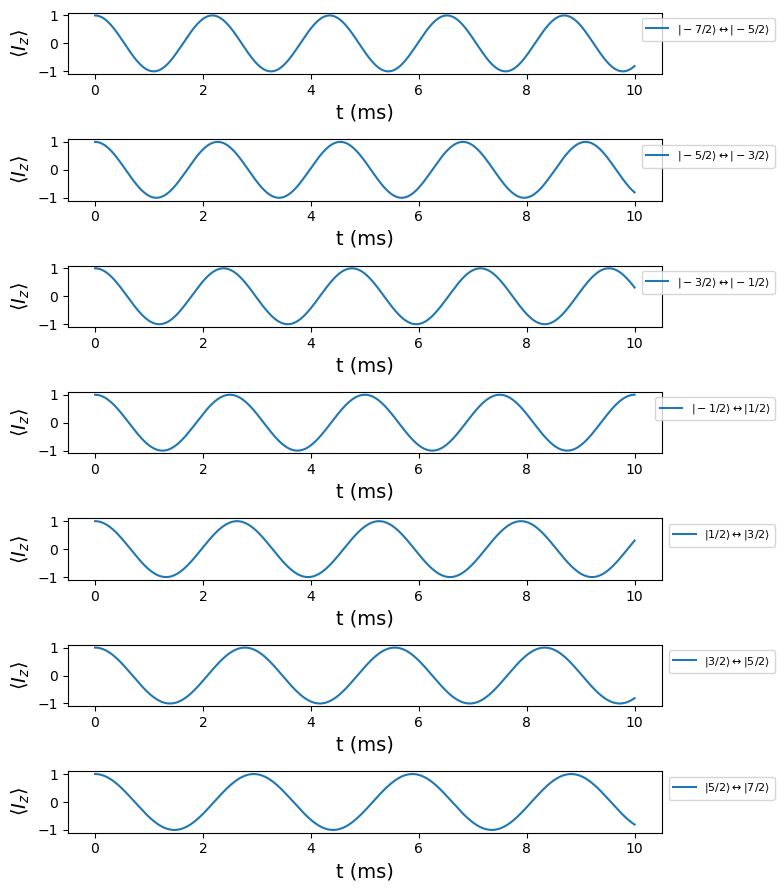

In [87]:
init_states = [0, 1, 2, 3, 4, 5, 6]
T = 10e-3
nmr_amp = 1e3
detIz = 400
detIz2 = 10


Hstatic = 2*np.pi*(detIz * Iz + detIz2 * Iz**2)

exp_ops = [qt.basis(8, i) * qt.basis(8, i+1).dag() + qt.basis(8, i+1) * qt.basis(8, i).dag() for i in range(7)]  # projectors onto each state

fig, ax = plt.subplots(7, figsize=(8, 9))

for state in init_states:
    init_state = (qt.basis(8, state) + qt.basis(8, state+1)).unit()
    ps = PulseSequence(dt=1e-6)
    ps.NMR.wait(T=T)
    ps.finish_pulse_sequence()
    # ps.plot_signal()
    
    H_drive, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=10)
    sim_result = qt.mesolve([Hstatic, *H_drive], init_state, time_array, e_ops=[*exp_ops], options={'store_states': True})
    Iz_exp_values.append(sim_result.expect[state])

    plt.sca(ax[state])
    plt.plot(time_array*1e3, np.real(sim_result.expect[state]), label=transition_dict[state])
    plt.ylabel('$\langle I_z \\rangle$', fontsize=14)
    plt.xlabel('t (ms)', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=8)
fig.tight_layout()
    # plt.title(f'Initial state: |{state}>')


In [ ]:
init_states = [0, 1, 2, 3, 4, 5, 6]
T = 1e-3
nmr_amp = 2e3
detIz = 0
detIz2 = 0.00

wait_array = np.linspace(0, 1, )
ps = PulseSequence(dt=1e-6)
pi_times = NMR.calculate_default_pi_times()

Hstatic = detIz * Iz + detIz2 * Iz**2
Iz_exp_values = []
fig = plt.figure(figsize=(8, 4))

for state in init_states:
    for tau in time_array
    init_state = qt.basis(8, state)
    
    ps.NMR.single_freq_drive(state, T=T, amp=nmr_amp)
    ps.NMR.default_amp = nmr_amp
    ps.NMR.calculate_default_pi_times()
    ps.NMR.pi_half_pulse(state)
    ps.wait()
    ps.finish_pulse_sequence()
    # ps.plot_signal()
    
    H_drive, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=10)
    sim_result = qt.mesolve([Hstatic, *H_drive], init_state, time_array, e_ops=[Iz], options={'store_states': True})
    Iz_exp_values.append(sim_result.expect[0])

    # plt.sca(fig.gca())
    plt.plot(time_array*1e3, np.real(sim_result.expect[0]), label=transition_dict[state])
    for i in range(0, 8):
        plt.hlines((i-3.5), time_array[0]*1e3, time_array[-1]*1e3, colors='k', linestyles='dashed', alpha=0.5)
    plt.ylabel('$\langle I_z \\rangle$', fontsize=14)
    plt.xlabel('t (ms)', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=8)
    # plt.title(f'Initial state: |{state}>')


# Global Rabi

In [60]:
ps.DriveSignal.drive_signals

{'NMR': [], 'NER1': [], 'NER2': []}

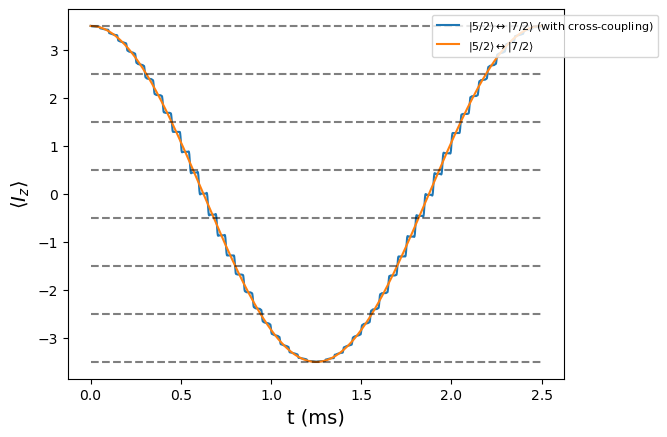

In [72]:

nmr_amp = 400
T = 1/nmr_amp
detIz = 0
detIz2 = 0.00

init_state = qt.basis(8, 0)
ps = PulseSequence(dt=1e-6)
ps.NMR.global_pulse(T=T, amp=nmr_amp)
ps.finish_pulse_sequence()
# ps.plot_signal()

H_drive, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=10)
H_drive_with_cross_coupling, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies)

sim_result_no_cross_coupling = qt.mesolve([Hstatic, *H_drive], init_state, time_array, e_ops=[Iz], options={'store_states': False})
sim_result_with_cross_coupling = qt.mesolve([Hstatic, *H_drive_with_cross_coupling], init_state, time_array, e_ops=[Iz], options={'store_states': False})


# plt.sca(fig.gca())
plt.plot(time_array*1e3, np.real(sim_result_with_cross_coupling.expect[0]), label=transition_dict[state] + ' (with cross-coupling)')
plt.plot(time_array*1e3, np.real(sim_result_no_cross_coupling.expect[0]), label=transition_dict[state])

for i in range(0, 8):
    plt.hlines((i-3.5), time_array[0]*1e3, time_array[-1]*1e3, colors='k', linestyles='dashed', alpha=0.5)
plt.ylabel('$\langle I_z \\rangle$', fontsize=14)
plt.xlabel('t (ms)', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=8)
# plt.title(f'Initial state: |{state}>')

# Ladder

In [99]:
ps.DriveSignal.drive_signals

{'NMR': [[(400+0j)],
  [(400+0j)],
  [(400+0j)],
  [(400+0j)],
  [(400+0j)],
  [(400+0j)],
  [(400+0j)]],
 'NER1': [],
 'NER2': [[np.complex128(1e-34+0j)],
  [np.complex128(1e-34+0j)],
  [np.complex128(1e-34+0j)],
  [np.complex128(1e-34+0j)],
  [np.complex128(1e-34+0j)],
  [np.complex128(1e-34+0j)]]}

In [109]:
time_array

array([0.00e+00, 1.00e-07, 2.00e-07, 3.00e-07, 4.00e-07, 5.00e-07,
       6.00e-07, 7.00e-07, 8.00e-07, 9.00e-07, 1.00e-06, 1.10e-06,
       1.20e-06, 1.30e-06, 1.40e-06, 1.50e-06, 1.60e-06, 1.70e-06,
       1.80e-06, 1.90e-06, 2.00e-06, 2.10e-06, 2.20e-06, 2.30e-06,
       2.40e-06, 2.50e-06, 2.60e-06, 2.70e-06, 2.80e-06, 2.90e-06,
       3.00e-06, 3.10e-06, 3.20e-06, 3.30e-06, 3.40e-06, 3.50e-06,
       3.60e-06, 3.70e-06, 3.80e-06, 3.90e-06, 4.00e-06, 4.10e-06,
       4.20e-06, 4.30e-06, 4.40e-06, 4.50e-06, 4.60e-06, 4.70e-06,
       4.80e-06, 4.90e-06, 5.00e-06, 5.10e-06, 5.20e-06, 5.30e-06,
       5.40e-06, 5.50e-06, 5.60e-06, 5.70e-06, 5.80e-06, 5.90e-06,
       6.00e-06, 6.10e-06, 6.20e-06, 6.30e-06, 6.40e-06, 6.50e-06,
       6.60e-06, 6.70e-06, 6.80e-06, 6.90e-06, 7.00e-06, 7.10e-06,
       7.20e-06, 7.30e-06, 7.40e-06, 7.50e-06, 7.60e-06, 7.70e-06,
       7.80e-06, 7.90e-06, 8.00e-06, 8.10e-06, 8.20e-06, 8.30e-06,
       8.40e-06, 8.50e-06, 8.60e-06, 8.70e-06, 8.80e-06, 8.90e

C:\Users\z5459883\AppData\Local\Temp\ipykernel_52468\2567503588.py:548: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = mpl.cm.get_cmap(self.colormaps[drive])(np.linspace(0.4, 1, len(self.drive_signals[drive])))


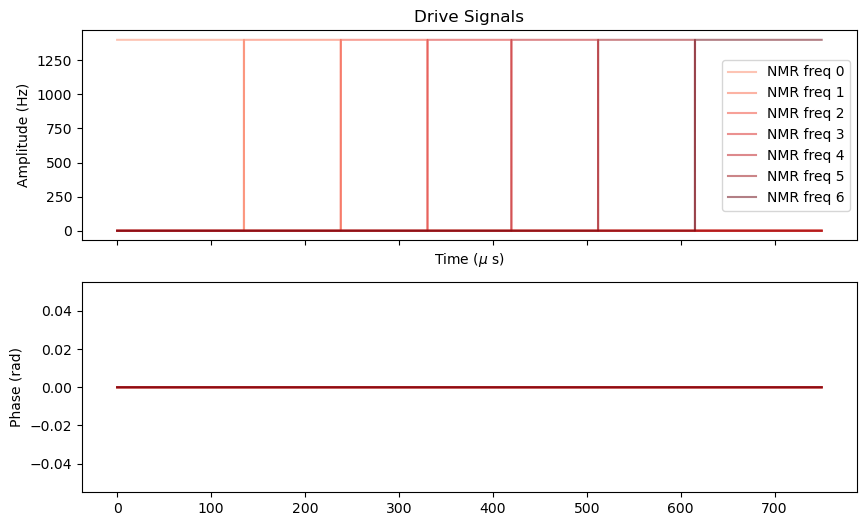

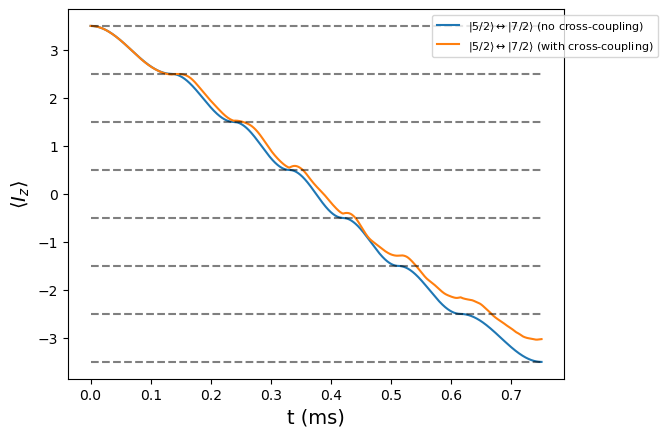

In [123]:

nmr_amp = 200*7
ix_amps = np.real(np.diag(Ix.full(), 1))

detIz = 0
detIz2 = 0.0

Hstatic = 2*np.pi*(detIz * Iz + detIz2 * Iz**2)

init_state = qt.basis(8, 0)
ps = PulseSequence(dt=1e-7)
for i in range(7):
    ps.NMR.single_freq_drive(i, T=0.5*0.5/(ix_amps[i]*nmr_amp), amp=nmr_amp)
    ps.align()
ps.finish_pulse_sequence()
ps.plot_signal()

H_drive, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=10)
H_drive_with_cross_coupling, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=1e32)

sim_result_no_cross_coupling = qt.mesolve([Hstatic, *H_drive], init_state, time_array, e_ops=[Iz], options={'store_states': False})
sim_result_with_cross_coupling = qt.mesolve([Hstatic, *H_drive_with_cross_coupling], init_state, time_array, e_ops=[Iz], options={'store_states': False})


# plt.sca(fig.gca())
plt.plot(time_array*1e3, np.real(sim_result_no_cross_coupling.expect[0]), label=transition_dict[state] + ' (no cross-coupling)')
plt.plot(time_array*1e3, np.real(sim_result_with_cross_coupling.expect[0]), label=transition_dict[state] + ' (with cross-coupling)')

for i in range(0, 8):
    plt.hlines((i-3.5), time_array[0]*1e3, time_array[-1]*1e3, colors='k', linestyles='dashed', alpha=0.5)
plt.ylabel('$\langle I_z \\rangle$', fontsize=14)
plt.xlabel('t (ms)', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=8)
# plt.title(f'Initial state: |{state}>')

In [ ]:
# Cat

# cat sabalizer

For drive  NER1  the number of frequencies does not match the number of coupling elements of the operator. Cannot set self-consistent detuning.


C:\Users\z5459883\AppData\Local\Temp\ipykernel_52468\2567503588.py:548: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = mpl.cm.get_cmap(self.colormaps[drive])(np.linspace(0.4, 1, len(self.drive_signals[drive])))


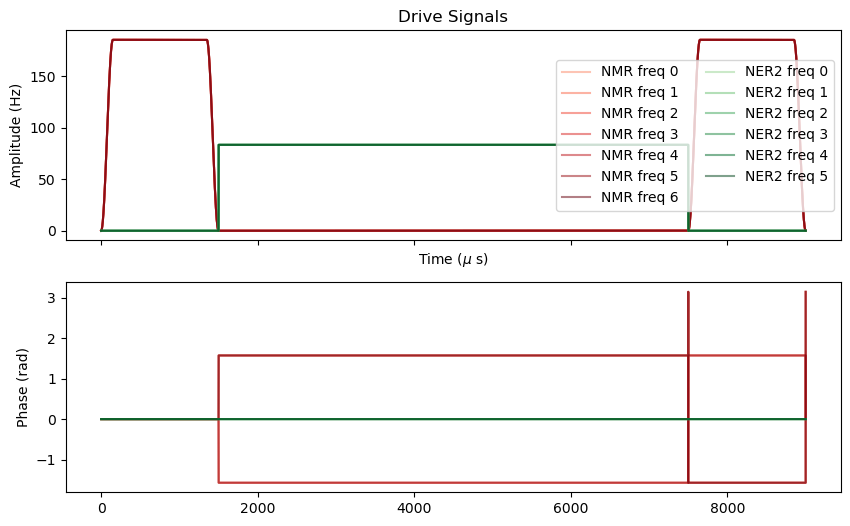

In [125]:
resonance_frequencies  = nmr_f
Hstatic = 0 * Iz + 0.01 * Iz**2
init_state = qt.basis(8, 7)

ps = PulseSequence(dt=1e-7)
ps.NMR.global_pulse(T=Tenc, amp=aGR, pulse_shape=sin_rise_fall)
ps.NMR.frame_rotation([np.pi/2, -np.pi/2, np.pi/2, -np.pi/2, np.pi/2, -np.pi/2, np.pi/2])
ps.align()
# ps.set_selfconsistent_detuning(np.arange(-3, 4) * aGR)  
ps.DriveSignal.set_RF_detuning(np.arange(-3, 4) * aGR)
ps.NER2.global_pulse(T=Tenc*4, amp=aGR/2, pulse_shape=None)
ps.align()
ps.set_selfconsistent_detuning(np.zeros(7))  
ps.NMR.global_pulse(T=Tenc, amp=-aGR, pulse_shape=sin_rise_fall)
ps.finish_pulse_sequence()
ps.plot_signal()

In [126]:
H_drive, time_array = ps.get_drive_hamiltonian(rotating_frame_frequencies=resonance_frequencies, cross_coupling_cutoff_frequency=10)
sim_result = qt.mesolve([Hstatic, *H_drive], init_state, time_array, e_ops=[*fock_dms], options={'store_states': True})
sim_result.states

[Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [1.]],
 Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[-3.10076106e-111+8.33749666e-127j]
  [-4.61743587e-096-2.67510074e-090j]
  [-1.56151734e-079-3.13760830e-067j]
  [ 1.84915772e-046-3.19951290e-056j]
  [ 1.87810444e-027-7.89731240e-036j]
  [ 1.71001850e-017-7.94824046e-025j]
  [ 1.58700726e-009-1.07037706e-016j]
  [ 1.00000000e+000-1.22500000e-008j]],
 Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[-7.82220660e-111+2.10327788e-126j]
  [-1.16482814e-095-6.74840475e-090j]
  [-3.93919783e-079-7.91516014e-067j]
  [ 4.66482049e-046-8.07132521e-056j]
  [ 4.73784360e-027-1.99223378e-035j]
  [ 4.31381771e-017-2.00508126e-024j]
  [ 3.99310627e-009-2.69977438e-016j]
  [ 1.00000000e+000-2.45000000e-008j]],
 Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qo

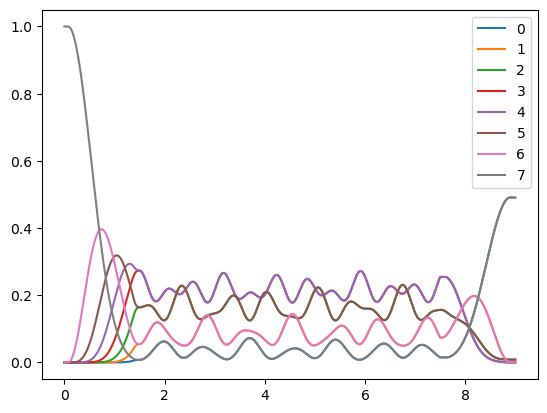

In [127]:
for i, exp in enumerate(sim_result.expect):
    plt.plot(time_array*1e3, np.real(exp), label=f'{i}')

plt.legend()